In [27]:
import os
import joblib
import mlflow
import mlflow.pytorch
import torch

from dotenv import load_dotenv
from mlflow.tracking import MlflowClient

# Load MLFLOW_URI from the project's .env file
load_dotenv(".env")
mlflow.set_tracking_uri(os.environ["MLFLOW_URI"])

EXPERIMENT_NAME = "soh-training"

# Automatically select the latest Data4 fine-tuning run
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

runs = MlflowClient().search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.stage = 'data4'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
)

if not runs:
    raise RuntimeError("No Data4 MLflow run was found")

run_id = runs[0].info.run_id
print("Using MLflow run:", run_id)

# Load the PyTorch model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = mlflow.pytorch.load_model(f"runs:/{run_id}/model")
model = model.to(device)
model.eval()

# Download and load the fitted StandardScaler
scaler_path = mlflow.artifacts.download_artifacts(
    run_id=run_id,
    artifact_path="training_outputs/scaler.joblib",
)

scaler = joblib.load(scaler_path)

print("Device:", device)
print("Model loaded:", type(model).__name__)
print("Scaler loaded:", type(scaler).__name__)

Using MLflow run: 3a34216a15b4417e81f9a9e223852830


Device: cuda
Model loaded: Multimodal
Scaler loaded: StandardScaler


In [28]:
import yaml

from src.data.datasets import (
    DATA4_FEATURES_COLS,
    Data4MultimodalDataset,
    generate_windows,
    load_data4_features,
    soh_to_image,
)
from src.training.train import split_group_ids

# Load the same configuration used for training
with open("config.yaml", encoding="utf-8") as file:
    config = yaml.safe_load(file)

seed = int(config["training"]["seed"])
split_config = config["training"]["splits"]["data4"]

# Load unscaled processed Data4 features
data = load_data4_features()

# Reproduce the original train/validation/test vehicle split
split = split_group_ids(data, split_config, seed)

print("Test vehicle IDs:", split["test"])

# Select the first held-out vehicle
vehicle_id = split["test"][0]
print("Selected vehicle:", vehicle_id)

# Keep the unscaled SOH because it is used to build the input image
scaled_data = data.copy()
scaled_data["soh_history_raw"] = scaled_data["SOH_hist"].astype(float)

# Apply the scaler loaded from MLflow
scaled_data.loc[:, DATA4_FEATURES_COLS] = scaler.transform(
    scaled_data[DATA4_FEATURES_COLS]
)

# Generate valid 100-history + 10-future windows
all_windows = generate_windows(scaled_data)

vehicle_windows = all_windows[
    all_windows["vehicle_id"] == vehicle_id
].reset_index(drop=True)

vehicle_data = scaled_data[
    scaled_data["vehicle_id"] == vehicle_id
].copy()

test_vehicle_dataset = Data4MultimodalDataset(
    windows=vehicle_windows,
    vehicles=vehicle_data,
    feature_cols=DATA4_FEATURES_COLS,
    soh_to_image=soh_to_image,
)

print("Number of inference windows:", len(test_vehicle_dataset))

Test vehicle IDs: [3, 67, 36]
Selected vehicle: 3
Number of inference windows: 274


In [29]:
import pandas as pd

from src.data.datasets import (
    HISTORY_LENGTH,
    PREDICTION_LENGTH,
    image_to_soh,
)

window_index = 1

(
    input_image,
    feature_sequence,
    _,
    true_future_soh,
    average_soh,
    last_observed_soh,
) = test_vehicle_dataset[window_index]

with torch.inference_mode():
    predicted_image = model(
        input_image.unsqueeze(0).to(device),       # [1, 256, 256]
        feature_sequence.unsqueeze(0).to(device), # [1, 100, n_features]
    )

# Decode the predicted image into a 110-point SOH trajectory
predicted_trajectory = image_to_soh(
    predicted_image[0],
    avg=average_soh.item(),
    n_points=HISTORY_LENGTH + PREDICTION_LENGTH,
)

# Keep only the next 10 predicted cycles
predicted_future_soh = predicted_trajectory[-PREDICTION_LENGTH:]

results = pd.DataFrame(
    {
        "horizon": range(1, PREDICTION_LENGTH + 1),
        "predicted_soh": predicted_future_soh,
        "true_soh": true_future_soh.numpy(),
    }
)

print("Vehicle:", vehicle_id)
print("Last observed SOH:", last_observed_soh.item())

results

Vehicle: 3
Last observed SOH: 0.9659443497657776


,horizon,predicted_soh,true_soh
0,1,0.961901,0.956592
1,2,0.962941,0.956363
2,3,0.962135,0.956132
3,4,0.961542,0.955899
4,5,0.961608,0.955665
5,6,0.961254,0.955429
6,7,0.961562,0.955191
7,8,0.953204,0.954951
8,9,0.996543,0.954710
9,10,1.045279,0.954468


<Axes: title={'center': 'SOH forecast — vehicle 3'}, xlabel='horizon', ylabel='SOH'>

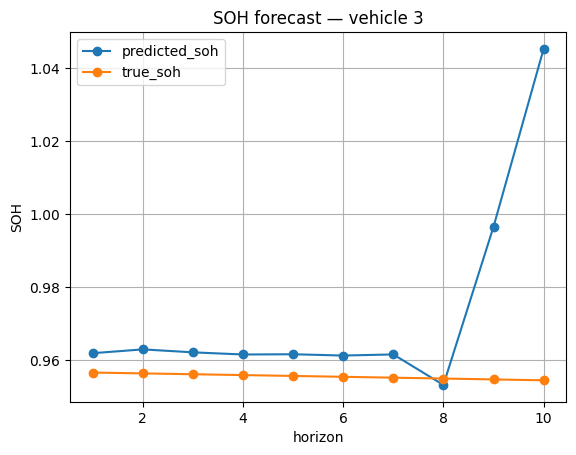

In [30]:
results.plot(
    x="horizon",
    y=["predicted_soh", "true_soh"],
    marker="o",
    grid=True,
    title=f"SOH forecast — vehicle {vehicle_id}",
    ylabel="SOH",
)

In [31]:
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.data.datasets import (
    HISTORY_LENGTH,
    PREDICTION_LENGTH,
    image_to_soh,
)

# test_vehicle_dataset and vehicle_id come from the previous notebook cells
loader = DataLoader(
    test_vehicle_dataset,
    batch_size=16,
    shuffle=False,
)

# Each vehicle position can receive predictions from several overlapping windows
prediction_buckets = defaultdict(list)

window_cursor = 0

model.eval()

with torch.inference_mode():
    for batch in loader:
        (
            input_images,
            feature_sequences,
            _,
            _,
            average_soh,
            _,
        ) = batch

        predicted_images = model(
            input_images.to(device),
            feature_sequences.to(device),
        )

        batch_size = predicted_images.shape[0]

        for batch_index in range(batch_size):
            # Decode the predicted image into a 110-point trajectory
            decoded_trajectory = image_to_soh(
                predicted_images[batch_index],
                avg=average_soh[batch_index].item(),
                n_points=HISTORY_LENGTH + PREDICTION_LENGTH,
            )

            future_prediction = decoded_trajectory[-PREDICTION_LENGTH:]

            window = test_vehicle_dataset.windows.iloc[
                window_cursor + batch_index
            ]

            start = int(window["start"])

            for horizon_index, predicted_soh in enumerate(
                future_prediction,
                start=1,
            ):
                # Horizon 1 corresponds to start + HISTORY_LENGTH
                vehicle_position = (
                    start + HISTORY_LENGTH + horizon_index - 1
                )

                prediction_buckets[vehicle_position].append(
                    {
                        "prediction": float(predicted_soh),
                        "horizon": horizon_index,
                    }
                )

        window_cursor += batch_size

In [32]:
aggregated_predictions = {}

for position, forecasts in prediction_buckets.items():
    values = np.array(
        [item["prediction"] for item in forecasts],
        dtype=float,
    )

    horizons = np.array(
        [item["horizon"] for item in forecasts],
        dtype=float,
    )

    # Give more weight to short-horizon forecasts
    weights = 1.0 / horizons

    aggregated_predictions[position] = {
        "predicted_soh": np.average(values, weights=weights),
        "prediction_std": np.std(values),
        "number_of_forecasts": len(values),
        "minimum_horizon": int(horizons.min()),
        "maximum_horizon": int(horizons.max()),
    }

In [33]:
# Use the original, unscaled vehicle data for reporting and plotting
raw_vehicle = (
    data[data["vehicle_id"] == vehicle_id]
    .sort_values("charge_block_id")
    .reset_index(drop=True)
    .copy()
)

trajectory_results = raw_vehicle[
    [
        "vehicle_id",
        "charge_block_id",
        "SOH_hist",
        "SOH_ref",
    ]
].copy()

trajectory_results["position"] = np.arange(len(trajectory_results))
trajectory_results["predicted_soh"] = np.nan
trajectory_results["prediction_std"] = np.nan
trajectory_results["number_of_forecasts"] = 0
trajectory_results["minimum_horizon"] = np.nan
trajectory_results["maximum_horizon"] = np.nan

for position, result in aggregated_predictions.items():
    trajectory_results.loc[position, "predicted_soh"] = (
        result["predicted_soh"]
    )
    trajectory_results.loc[position, "prediction_std"] = (
        result["prediction_std"]
    )
    trajectory_results.loc[position, "number_of_forecasts"] = (
        result["number_of_forecasts"]
    )
    trajectory_results.loc[position, "minimum_horizon"] = (
        result["minimum_horizon"]
    )
    trajectory_results.loc[position, "maximum_horizon"] = (
        result["maximum_horizon"]
    )

trajectory_results.head(HISTORY_LENGTH + 5)

,vehicle_id,charge_block_id,SOH_hist,SOH_ref,position,predicted_soh,prediction_std,number_of_forecasts,minimum_horizon,maximum_horizon
0,3,3,0.961036,0.969604,0,NaN,NaN,0,NaN,NaN
1,3,7,0.961036,0.969571,1,NaN,NaN,0,NaN,NaN
2,3,8,0.961036,0.969536,2,NaN,NaN,0,NaN,NaN
3,3,9,0.961349,0.969499,3,NaN,NaN,0,NaN,NaN
4,3,11,0.975792,0.969459,4,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
100,3,225,0.965944,0.956819,100,0.960795,0.000000,1,1.0,1.0
101,3,227,0.965944,0.956592,101,0.961483,0.000628,2,1.0,2.0
102,3,230,0.966220,0.956363,102,0.961352,0.002188,3,1.0,3.0
103,3,232,0.966068,0.956132,103,0.963816,0.001530,4,1.0,4.0


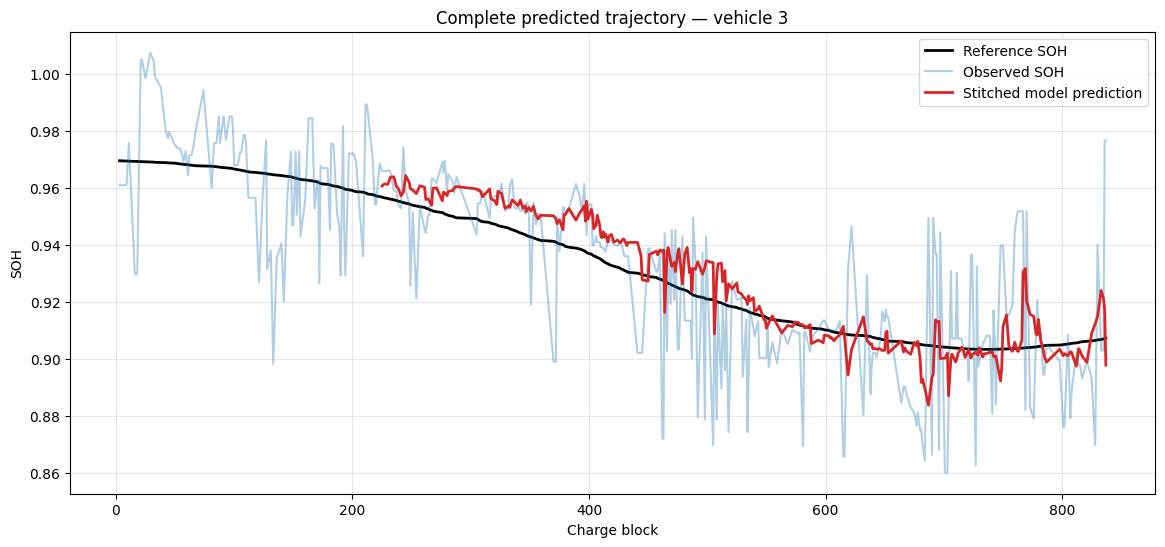

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    trajectory_results["charge_block_id"],
    trajectory_results["SOH_ref"],
    label="Reference SOH",
    color="black",
    linewidth=2,
)

plt.plot(
    trajectory_results["charge_block_id"],
    trajectory_results["SOH_hist"],
    label="Observed SOH",
    color="tab:blue",
    alpha=0.35,
)

plt.plot(
    trajectory_results["charge_block_id"],
    trajectory_results["predicted_soh"],
    label="Stitched model prediction",
    color="tab:red",
    linewidth=2,
)

plt.xlabel("Charge block")
plt.ylabel("SOH")
plt.title(f"Complete predicted trajectory — vehicle {vehicle_id}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [35]:
trajectory_results[
    [
        "charge_block_id",
        "SOH_ref",
        "predicted_soh",
        "prediction_std",
        "number_of_forecasts",
        "minimum_horizon",
        "maximum_horizon",
    ]
].tail(15)

,charge_block_id,SOH_ref,predicted_soh,prediction_std,number_of_forecasts,minimum_horizon,maximum_horizon
368,805,0.905227,0.901102,0.028122,10,1.0,10.0
369,807,0.905352,0.902572,0.028164,10,1.0,10.0
370,808,0.905482,0.902319,0.027893,10,1.0,10.0
371,812,0.905616,0.897435,0.029377,10,1.0,10.0
372,814,0.905753,0.903640,0.026801,10,1.0,10.0
373,815,0.905896,0.902986,0.027187,10,1.0,10.0
374,817,0.906042,0.901003,0.028363,9,2.0,10.0
375,821,0.906193,0.898802,0.013735,8,3.0,10.0
376,825,0.906348,0.909009,0.031745,7,4.0,10.0
377,828,0.906508,0.912353,0.033111,6,5.0,10.0


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.datasets import (
    HISTORY_LENGTH,
    PREDICTION_LENGTH,
    image_to_soh,
)

raw_vehicle = (
    data[data["vehicle_id"] == vehicle_id]
    .sort_values("charge_block_id")
    .reset_index(drop=True)
    .copy()
)

non_overlapping_results = raw_vehicle[
    [
        "vehicle_id",
        "charge_block_id",
        "SOH_hist",
        "SOH_ref",
    ]
].copy()

non_overlapping_results["predicted_soh"] = np.nan
non_overlapping_results["forecast_block"] = np.nan
non_overlapping_results["horizon"] = np.nan

# Select window 0, 10, 20, 30, ...
selected_window_indices = list(
    range(
        0,
        len(test_vehicle_dataset),
        PREDICTION_LENGTH,
    )
)

model.eval()

with torch.inference_mode():
    for block_number, window_index in enumerate(selected_window_indices):
        (
            input_image,
            feature_sequence,
            _,
            _,
            average_soh,
            _,
        ) = test_vehicle_dataset[window_index]

        predicted_image = model(
            input_image.unsqueeze(0).to(device),
            feature_sequence.unsqueeze(0).to(device),
        )

        decoded_trajectory = image_to_soh(
            predicted_image[0],
            avg=average_soh.item(),
            n_points=HISTORY_LENGTH + PREDICTION_LENGTH,
        )

        future_prediction = decoded_trajectory[-PREDICTION_LENGTH:]

        window = test_vehicle_dataset.windows.iloc[window_index]
        window_start = int(window["start"])
        prediction_start = window_start + HISTORY_LENGTH

        for horizon_index, predicted_soh in enumerate(
            future_prediction,
            start=1,
        ):
            vehicle_position = prediction_start + horizon_index - 1

            non_overlapping_results.loc[
                vehicle_position, "predicted_soh"
            ] = predicted_soh

            non_overlapping_results.loc[
                vehicle_position, "forecast_block"
            ] = block_number

            non_overlapping_results.loc[
                vehicle_position, "horizon"
            ] = horizon_index

In [37]:
last_predicted_position = (
    non_overlapping_results["predicted_soh"].last_valid_index()
)

if (
    last_predicted_position is not None
    and last_predicted_position < len(non_overlapping_results) - 1
):
    final_window_index = len(test_vehicle_dataset) - 1

    (
        input_image,
        feature_sequence,
        _,
        _,
        average_soh,
        _,
    ) = test_vehicle_dataset[final_window_index]

    with torch.inference_mode():
        predicted_image = model(
            input_image.unsqueeze(0).to(device),
            feature_sequence.unsqueeze(0).to(device),
        )

    decoded_trajectory = image_to_soh(
        predicted_image[0],
        avg=average_soh.item(),
        n_points=HISTORY_LENGTH + PREDICTION_LENGTH,
    )

    future_prediction = decoded_trajectory[-PREDICTION_LENGTH:]

    final_window = test_vehicle_dataset.windows.iloc[final_window_index]
    prediction_start = int(final_window["start"]) + HISTORY_LENGTH

    for horizon_index, predicted_soh in enumerate(
        future_prediction,
        start=1,
    ):
        vehicle_position = prediction_start + horizon_index - 1

        # Fill only positions not already predicted
        if np.isnan(
            non_overlapping_results.loc[
                vehicle_position, "predicted_soh"
            ]
        ):
            non_overlapping_results.loc[
                vehicle_position, "predicted_soh"
            ] = predicted_soh

            non_overlapping_results.loc[
                vehicle_position, "forecast_block"
            ] = len(selected_window_indices)

            non_overlapping_results.loc[
                vehicle_position, "horizon"
            ] = horizon_index

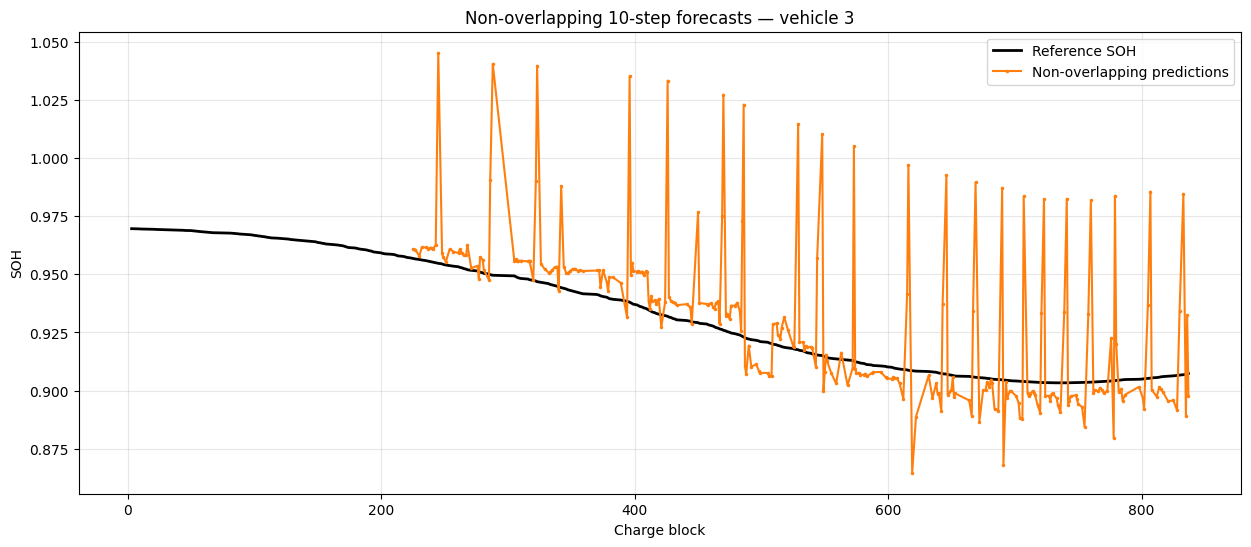

In [38]:
plt.figure(figsize=(15, 6))

plt.plot(
    non_overlapping_results["charge_block_id"],
    non_overlapping_results["SOH_ref"],
    label="Reference SOH",
    color="black",
    linewidth=2,
)

plt.plot(
    non_overlapping_results["charge_block_id"],
    non_overlapping_results["predicted_soh"],
    label="Non-overlapping predictions",
    color="tab:orange",
    linewidth=1.5,
    marker=".",
    markersize=3,
)

plt.xlabel("Charge block")
plt.ylabel("SOH")
plt.title(
    f"Non-overlapping 10-step forecasts — vehicle {vehicle_id}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

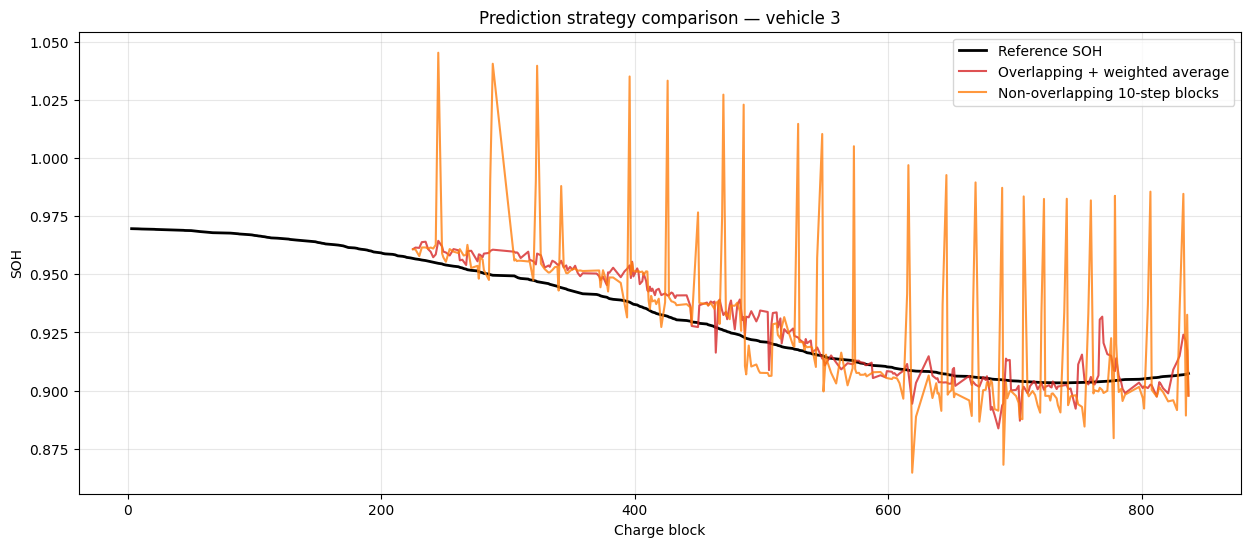

In [39]:
plt.figure(figsize=(15, 6))

plt.plot(
    non_overlapping_results["charge_block_id"],
    non_overlapping_results["SOH_ref"],
    label="Reference SOH",
    color="black",
    linewidth=2,
)

plt.plot(
    trajectory_results["charge_block_id"],
    trajectory_results["predicted_soh"],
    label="Overlapping + weighted average",
    color="tab:red",
    alpha=0.8,
)

plt.plot(
    non_overlapping_results["charge_block_id"],
    non_overlapping_results["predicted_soh"],
    label="Non-overlapping 10-step blocks",
    color="tab:orange",
    alpha=0.8,
)

plt.xlabel("Charge block")
plt.ylabel("SOH")
plt.title(f"Prediction strategy comparison — vehicle {vehicle_id}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Post-training comparison: lab pretraining vs Data 4 fine-tuning

These cells use the artifacts produced by `python -m src.training.train`. They do not retrain the model. Run them after training finishes.

In [40]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

ARTIFACT_ROOT = Path("data/artifacts")
STAGE_PATHS = {
    "Lab pretraining": ARTIFACT_ROOT / "lab_pretraining",
    "Data 4 fine-tuning": ARTIFACT_ROOT / "data4_finetuning",
}

with open("config.yaml", encoding="utf-8") as file:
    training_config = yaml.safe_load(file)

required_files = [
    directory / filename
    for directory in STAGE_PATHS.values()
    for filename in (
        "best_model.pth",
        "history.csv",
        "metrics_by_horizon.csv",
        "scaler.joblib",
    )
]
missing_files = [str(path) for path in required_files if not path.is_file()]
if missing_files:
    raise RuntimeError(
        "Training artifacts are not ready yet:\n- " + "\n- ".join(missing_files)
    )

histories = {
    stage: pd.read_csv(directory / "history.csv")
    for stage, directory in STAGE_PATHS.items()
}
horizon_metrics = {
    stage: pd.read_csv(directory / "metrics_by_horizon.csv")
    for stage, directory in STAGE_PATHS.items()
}

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


### Overall comparison

Forecast MAE and RMSE are reconstructed from the ten saved horizon metrics. Values are also reported as SOH percentage points.

In [41]:
comparison_rows = []

for stage, directory in STAGE_PATHS.items():
    history = histories[stage]
    horizons = horizon_metrics[stage]
    best_row = history.loc[history["val_image_mse"].idxmin()]

    comparison_rows.append(
        {
            "stage": stage,
            "epochs_completed": len(history),
            "best_epoch": int(best_row["epoch"]),
            "best_val_image_mse": float(best_row["val_image_mse"]),
            "forecast_mae": float(horizons["mae"].mean()),
            "forecast_rmse": float(np.sqrt(np.mean(horizons["rmse"] ** 2))),
            "mae_percentage_points": float(horizons["mae"].mean() * 100),
            "rmse_percentage_points": float(
                np.sqrt(np.mean(horizons["rmse"] ** 2)) * 100
            ),
            "training_minutes": float(history["epoch_seconds"].sum() / 60),
            "checkpoint_mb": float(
                (directory / "best_model.pth").stat().st_size / 1024**2
            ),
        }
    )

comparison = pd.DataFrame(comparison_rows).set_index("stage")
comparison.style.format(
    {
        "best_val_image_mse": "{:.8f}",
        "forecast_mae": "{:.6f}",
        "forecast_rmse": "{:.6f}",
        "mae_percentage_points": "{:.4f}",
        "rmse_percentage_points": "{:.4f}",
        "training_minutes": "{:.2f}",
        "checkpoint_mb": "{:.1f}",
    }
)

,epochs_completed,best_epoch,best_val_image_mse,forecast_mae,forecast_rmse,mae_percentage_points,rmse_percentage_points,training_minutes,checkpoint_mb
stage,,,,,,,,,
Lab pretraining,1,1,0.00022465,0.000319,0.000750,0.0319,0.0750,28.52,94.9
Data 4 fine-tuning,13,3,0.00405447,0.014944,0.028417,1.4944,2.8417,33.20,94.9


### Training and validation loss

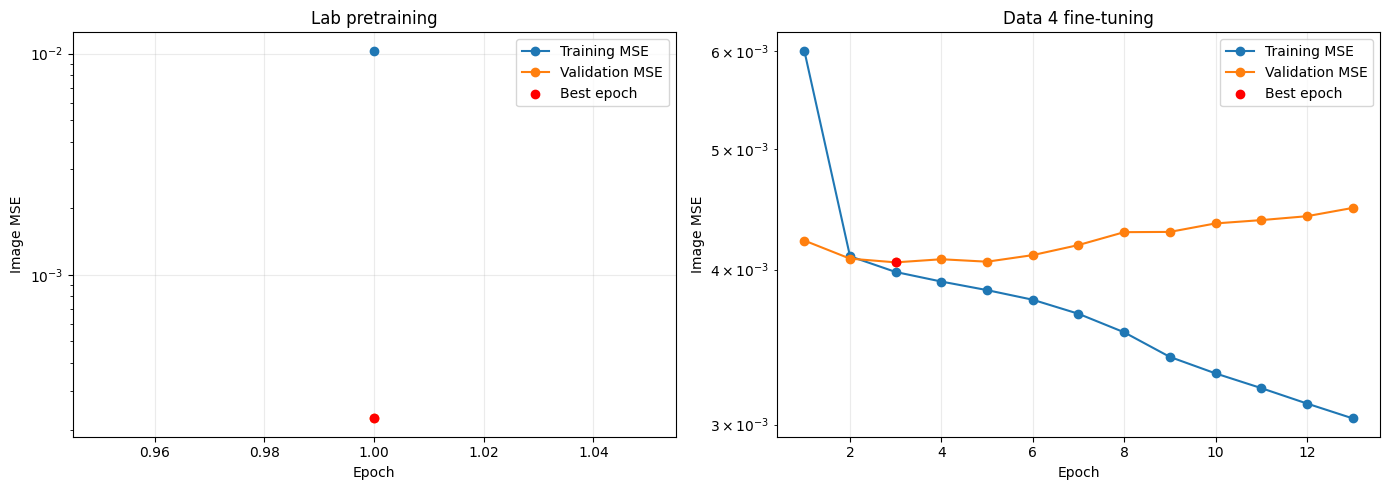

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, (stage, history) in zip(axes, histories.items()):
    axis.plot(
        history["epoch"],
        history["train_image_mse"],
        marker="o",
        label="Training MSE",
    )
    axis.plot(
        history["epoch"],
        history["val_image_mse"],
        marker="o",
        label="Validation MSE",
    )
    best_index = history["val_image_mse"].idxmin()
    best_epoch = int(history.loc[best_index, "epoch"])
    best_loss = float(history.loc[best_index, "val_image_mse"])
    axis.scatter(best_epoch, best_loss, color="red", zorder=5, label="Best epoch")
    axis.set_title(stage)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Image MSE")
    axis.set_yscale("log")
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

### Forecast error by horizon

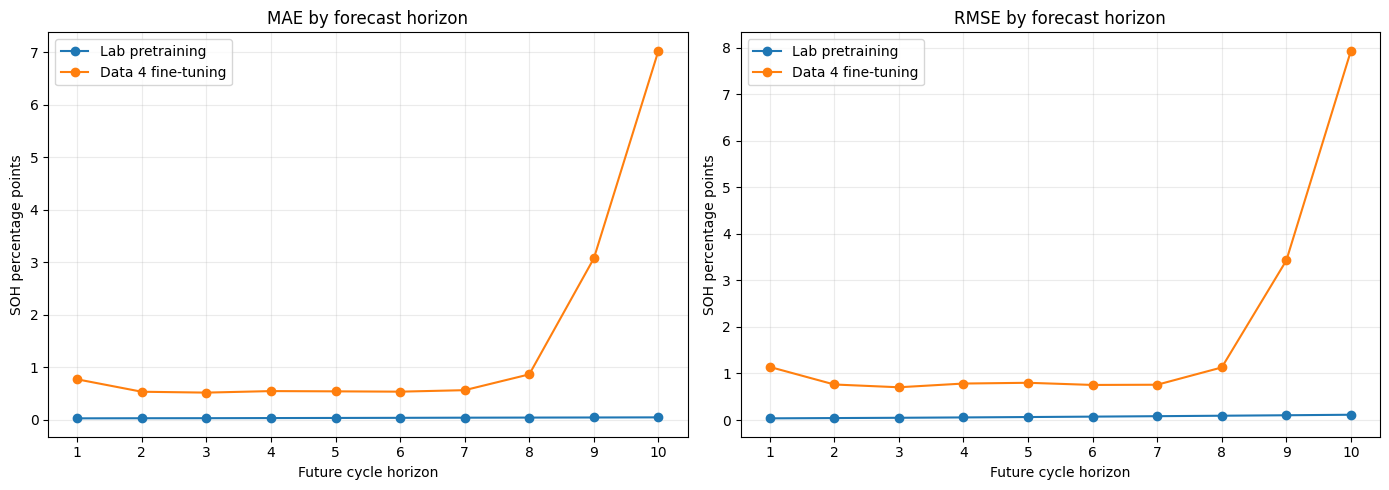

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for stage, metrics in horizon_metrics.items():
    axes[0].plot(
        metrics["horizon"], metrics["mae"] * 100, marker="o", label=stage
    )
    axes[1].plot(
        metrics["horizon"], metrics["rmse"] * 100, marker="o", label=stage
    )

axes[0].set_title("MAE by forecast horizon")
axes[1].set_title("RMSE by forecast horizon")
for axis in axes:
    axis.set_xlabel("Future cycle horizon")
    axis.set_ylabel("SOH percentage points")
    axis.set_xticks(range(1, 11))
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

### Early-stopping and learning-rate summary

In [44]:
stage_config_names = {
    "Lab pretraining": "lab",
    "Data 4 fine-tuning": "data4",
}

stopping_rows = []
for stage, history in histories.items():
    config_name = stage_config_names[stage]
    configured = training_config["training"][config_name]
    stopping_rows.append(
        {
            "stage": stage,
            "configured_max_epochs": configured["epochs"],
            "epochs_completed": len(history),
            "stopped_early": len(history) < configured["epochs"],
            "early_stopping_patience": configured["early_stopping_patience"],
            "initial_learning_rate": configured["learning_rate"],
            "final_learning_rate": history["learning_rate"].iloc[-1],
            "best_epoch": int(history.loc[history["val_image_mse"].idxmin(), "epoch"]),
        }
    )

pd.DataFrame(stopping_rows).set_index("stage")

,configured_max_epochs,epochs_completed,stopped_early,early_stopping_patience,initial_learning_rate,final_learning_rate,best_epoch
stage,,,,,,,
Lab pretraining,1,1,False,15,0.00010,0.000100,1
Data 4 fine-tuning,20,13,True,10,0.00001,0.000003,3


### MLflow run comparison

This retrieves run status and final logged metrics from the remote tracking server. The URI remains in `.env` and is not printed.

In [45]:
import os

import mlflow
from dotenv import load_dotenv

load_dotenv(".env")
mlflow.set_tracking_uri(os.environ["MLFLOW_URI"])
experiment = mlflow.get_experiment_by_name(training_config["mlflow"]["experiment_name"])

if experiment is None:
    raise RuntimeError("The configured MLflow experiment does not exist")

mlflow_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"],
)

wanted_columns = [
    "run_id",
    "status",
    "tags.stage",
    "tags.mlflow.runName",
    "metrics.train_image_mse",
    "metrics.val_image_mse",
    "metrics.image_mse",
    "metrics.forecast_mae",
    "metrics.forecast_rmse",
    "start_time",
    "end_time",
]
available_columns = [
    column for column in wanted_columns if column in mlflow_runs.columns
]

mlflow_runs[available_columns].head(10)

,run_id,status,tags.stage,tags.mlflow.runName,metrics.train_image_mse,metrics.val_image_mse,metrics.image_mse,metrics.forecast_mae,metrics.forecast_rmse,start_time,end_time
0,3a34216a15b4417e81f9a9e223852830,FINISHED,data4,data4-finetuning,0.003035,0.004486,0.003969,0.014944,0.028417,2026-09-25 12:44:01.864000+00:00,2026-09-25 13:17:44.055000+00:00
1,5ca32120b76e45b4a6ebc8fff322be34,FINISHED,lab,lab-pretraining,0.010302,0.000225,0.000196,0.000319,0.000750,2026-09-25 12:13:25.156000+00:00,2026-09-25 12:44:01.391000+00:00


### Interpretation checklist

- Use **validation image MSE** to identify overfitting and the best epoch.
- Use **test forecast MAE/RMSE** to compare predictive accuracy.
- Inspect horizon 10 separately; long-horizon degradation is often hidden by the average.
- Compare Data 4 train and validation curves to judge the effect of transfer learning.
- The lab and Data 4 errors are not directly equivalent datasets; compare trends as well as absolute values.